In [1]:
import torch
import torch.nn as nn
from torch.optim import Adam
import librosa
from torch.utils.data import DataLoader, Dataset
from sklearn.preprocessing import LabelEncoder
import pandas as pd

import numpy as np
import matplotlib.pyplot as plt
from skimage.transform import resize
print('lineya')
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

lineya
cuda


In [2]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    print(dirname)

/kaggle/input
/kaggle/input/datasets
/kaggle/input/datasets/naosinlineya
/kaggle/input/datasets/naosinlineya/quran-recitation
/kaggle/input/datasets/naosinlineya/quran-recitation/Dataset
/kaggle/input/datasets/naosinlineya/quran-recitation/Dataset/Dataset
/kaggle/input/datasets/naosinlineya/quran-recitation/Dataset/Dataset/AbdulRahman_Alsudais
/kaggle/input/datasets/naosinlineya/quran-recitation/Dataset/Dataset/Mohammed_Ayoub
/kaggle/input/datasets/naosinlineya/quran-recitation/Dataset/Dataset/Yasser_Aldossary
/kaggle/input/datasets/naosinlineya/quran-recitation/Dataset/Dataset/AbdulBari_Althubaity
/kaggle/input/datasets/naosinlineya/quran-recitation/Dataset/Dataset/Bander_Balilah
/kaggle/input/datasets/naosinlineya/quran-recitation/Dataset/Dataset/Saad_Alghamdi
/kaggle/input/datasets/naosinlineya/quran-recitation/Dataset/Dataset/Ali_Alhothaify
/kaggle/input/datasets/naosinlineya/quran-recitation/Dataset/Dataset/Abdullah_Albuaijan
/kaggle/input/datasets/naosinlineya/quran-recitation/Da

In [3]:
data_df = pd.read_csv("/kaggle/input/datasets/naosinlineya/quran-recitation/Dataset/files_paths.csv")
print(data_df.head())
data_df.Class.value_counts()


                                        FilePath               Class
0  ./Dataset/Mohammed_Aluhaidan/lohaidan_171.wav  Mohammed_Aluhaidan
1  ./Dataset/Mohammed_Aluhaidan/lohaidan_159.wav  Mohammed_Aluhaidan
2  ./Dataset/Mohammed_Aluhaidan/lohaidan_401.wav  Mohammed_Aluhaidan
3  ./Dataset/Mohammed_Aluhaidan/lohaidan_367.wav  Mohammed_Aluhaidan
4  ./Dataset/Mohammed_Aluhaidan/lohaidan_373.wav  Mohammed_Aluhaidan


Class
Saud_Alshuraim          696
Saad_Alghamdi           688
AbdulRahman_Alsudais    648
Yasser_Aldossary        576
Ali_Alhothaify          576
Bander_Balilah          576
Maher_Almuaiqly         576
Abdullah_Albuaijan      504
Mohammed_Ayoub          480
Nasser_Alqutami         456
AbdulBari_Althubaity    456
Mohammed_Aluhaidan      455
Name: count, dtype: int64

Text(0.5, 1.0, 'class distribution')

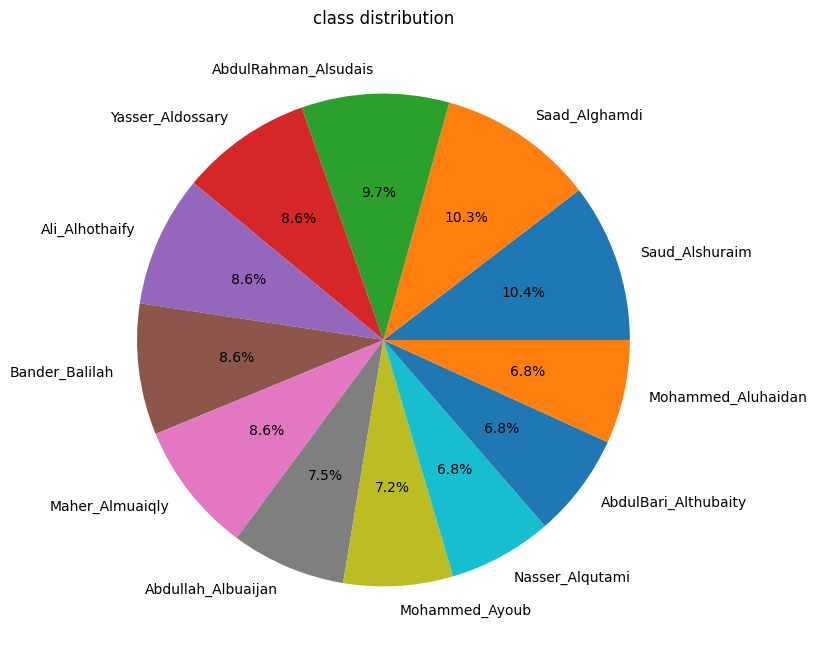

In [4]:
new_prefix = "/kaggle/input/datasets/naosinlineya/quran-recitation/Dataset/Dataset"
data_df['FilePath'] = data_df['FilePath'].str.replace(r'^\./Dataset', new_prefix, regex=True)


data_df['FilePath'][0]
data_df.shape

plt.figure(figsize=(8,8))
plt.pie(data_df['Class'].value_counts().values,labels=data_df.Class.value_counts().index,autopct='%1.1f%%')
plt.title("class distribution")

In [5]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    print(dirname)

/kaggle/input
/kaggle/input/datasets
/kaggle/input/datasets/naosinlineya
/kaggle/input/datasets/naosinlineya/quran-recitation
/kaggle/input/datasets/naosinlineya/quran-recitation/Dataset
/kaggle/input/datasets/naosinlineya/quran-recitation/Dataset/Dataset
/kaggle/input/datasets/naosinlineya/quran-recitation/Dataset/Dataset/AbdulRahman_Alsudais
/kaggle/input/datasets/naosinlineya/quran-recitation/Dataset/Dataset/Mohammed_Ayoub
/kaggle/input/datasets/naosinlineya/quran-recitation/Dataset/Dataset/Yasser_Aldossary
/kaggle/input/datasets/naosinlineya/quran-recitation/Dataset/Dataset/AbdulBari_Althubaity
/kaggle/input/datasets/naosinlineya/quran-recitation/Dataset/Dataset/Bander_Balilah
/kaggle/input/datasets/naosinlineya/quran-recitation/Dataset/Dataset/Saad_Alghamdi
/kaggle/input/datasets/naosinlineya/quran-recitation/Dataset/Dataset/Ali_Alhothaify
/kaggle/input/datasets/naosinlineya/quran-recitation/Dataset/Dataset/Abdullah_Albuaijan
/kaggle/input/datasets/naosinlineya/quran-recitation/Da

In [6]:
# data split
label_encoder=LabelEncoder()
data_df['Class']=label_encoder.fit_transform(data_df['Class'])
train=data_df.sample(frac=0.7,random_state=7)
test=data_df.drop(train.index)
val=test.sample(frac=0.5,random_state=7)
test=test.drop(val.index)
print(train.shape)
print(val.shape)
print(test.shape)
data_df['Class']
data_df['Class'].unique()

(4681, 2)
(1003, 2)
(1003, 2)


array([ 6, 11,  5,  8,  0,  4,  3, 10,  7,  1,  9,  2])

In [7]:


class CustomAudioDataset():
    def __init__(self,dataframe):
        self.dataframe=dataframe
        self.labels = torch.tensor(dataframe['Class'].to_numpy(),dtype=torch.long).to(device)
        self.audio=[torch.Tensor(self.get_spectrogram(path)).type(torch.FloatTensor) for path in dataframe['FilePath']]

    def __len__(self):
        return self.dataframe.shape[0]

    def __getitem__(self,idx):
       #img_path=self.dataframe.iloc[idx,0]
       label=self.labels[idx].to(device)
       audio = self.audio[idx].unsqueeze(0).to(device)
       return audio,label

    def get_spectrogram(self,file_path):
        sr=22050
        duration=5
        img_height=128
        img_width=256
        signal,sr=librosa.load(file_path,sr=sr,duration=duration)
        spec=librosa.feature.melspectrogram(y=signal,sr=sr,n_fft=2048,hop_length=512,n_mels=128)
        spec_db=librosa.power_to_db(spec,ref=np.max)
        target_frames = int((duration * sr) / 512 + 1)
        spec_resized = librosa.util.fix_length(spec_db, size=target_frames, axis=1)
        spec_resized=resize(spec_resized,(img_height,img_width),anti_aliasing=True)
        return spec_resized






        

In [8]:
train_dataset=CustomAudioDataset(train)
val_dataset=CustomAudioDataset(val)
test_dataset=CustomAudioDataset(test)

In [9]:
LR=1e-4
Batch_size=16
EPOCHS=25

In [10]:
train_loader=DataLoader(train_dataset,Batch_size,shuffle=True)
val_loader=DataLoader(val_dataset,Batch_size,shuffle=True)
test_loader=DataLoader(test_dataset,Batch_size,shuffle=True)

In [11]:
class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1=nn.Conv2d(1,16,kernel_size=3,padding=1)
        self.conv2=nn.Conv2d(16,32,kernel_size=3,padding=1)
        self.conv3=nn.Conv2d(32,64,kernel_size=3,padding=1)
        self.pooling=nn.MaxPool2d(2,2)
        self.relu=nn.ReLU()
        self.flatten=nn.Flatten()
        self.linear1=nn.Linear(64*16*32,4096)
        self.linear2=nn.Linear(4096,1024)
        self.linear3=nn.Linear(1024,512)
        self.output=nn.Linear(512,data_df['Class'].nunique())
        self.dropout=nn.Dropout(0.5)

    def forward(self,x):
        x=self.conv1(x)
        x=self.pooling(x)
        x=self.relu(x)
        x=self.conv2(x)
        x=self.pooling(x)
        x=self.relu(x)
        x=self.conv3(x)
        x=self.pooling(x)
        x=self.relu(x)

        
        
        x=self.flatten(x)
        x=self.linear1(x)
        x=self.relu(x)
        x=self.dropout(x)
        
        x=self.linear2(x)
        x=self.relu(x)
        x=self.dropout(x)
        
        x=self.linear3(x)
        x=self.relu(x)
        x=self.dropout(x)
        
        x=self.output(x)
        return x
        
model = Net().to(device) 
print(model)


Net(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pooling): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (relu): ReLU()
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linear1): Linear(in_features=32768, out_features=4096, bias=True)
  (linear2): Linear(in_features=4096, out_features=1024, bias=True)
  (linear3): Linear(in_features=1024, out_features=512, bias=True)
  (output): Linear(in_features=512, out_features=12, bias=True)
  (dropout): Dropout(p=0.5, inplace=False)
)


In [12]:
from torchsummary import summary
summary(model,(1,128,256))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 16, 128, 256]             160
         MaxPool2d-2          [-1, 16, 64, 128]               0
              ReLU-3          [-1, 16, 64, 128]               0
            Conv2d-4          [-1, 32, 64, 128]           4,640
         MaxPool2d-5           [-1, 32, 32, 64]               0
              ReLU-6           [-1, 32, 32, 64]               0
            Conv2d-7           [-1, 64, 32, 64]          18,496
         MaxPool2d-8           [-1, 64, 16, 32]               0
              ReLU-9           [-1, 64, 16, 32]               0
          Flatten-10                [-1, 32768]               0
           Linear-11                 [-1, 4096]     134,221,824
             ReLU-12                 [-1, 4096]               0
          Dropout-13                 [-1, 4096]               0
           Linear-14                 [-

In [13]:
loss=nn.CrossEntropyLoss()
optimizer=Adam(model.parameters(),lr=LR)
print('done')

done


In [14]:
total_loss_train_plt=[]
total_loss_val_plt=[]
total_acc_train_plt=[]
total_acc_val_plt=[]
import time
start_time=time.time()
for epoch in range (EPOCHS):
    total_acc_train=0
    total_loss_train=0
    total_loss_val=0
    total_acc_val=0
    for inputs , labels in train_loader:
        optimizer.zero_grad()
        output=model(inputs)
        train_loss=loss(output,labels)
        
        train_loss.backward()
        total_loss_train+=train_loss
        acc=(torch.argmax(output,axis=1)==labels).sum().item()
        total_acc_train+=acc
        
        optimizer.step()
        

    with torch.no_grad():
       
        for inputs , labels in val_loader:
            output=model(inputs)
            val_loss=loss(output,labels)
            
            total_loss_val+=val_loss
            acc=(torch.argmax(output,axis=1)==labels).sum().item()
            total_acc_val+=acc

    total_loss_train_plt.append(round(total_loss_train.item()/1000,4))
    total_loss_val_plt.append(round(total_loss_val.item()/1000,4))
    total_acc_train_plt.append(round(total_acc_train/train_dataset.__len__()*100,4))
    total_acc_val_plt.append(round(total_acc_val/val_dataset.__len__()*100,4))


    print("epoch:",epoch,"train loss:",round(total_loss_train.item()/1000,4),"train accuracy:",
          round(total_acc_train/train_dataset.__len__()*100,4),"validation loss:",
          round(total_loss_val.item()/1000,4),'validation accuracy:',
          (round(total_acc_val/val_dataset.__len__()*100,4)))
         
        
        
print('training time:' ,round(time.time()-start_time,4 ),'seconds')      
        


        
        

epoch: 0 train loss: 0.7024 train accuracy: 16.4068 validation loss: 0.1165 validation accuracy: 37.1884
epoch: 1 train loss: 0.3079 train accuracy: 65.1997 validation loss: 0.0361 validation accuracy: 79.3619
epoch: 2 train loss: 0.1094 train accuracy: 88.1008 validation loss: 0.0167 validation accuracy: 91.326
epoch: 3 train loss: 0.0532 train accuracy: 94.6165 validation loss: 0.0102 validation accuracy: 94.1176
epoch: 4 train loss: 0.0306 train accuracy: 96.8169 validation loss: 0.0102 validation accuracy: 95.015
epoch: 5 train loss: 0.0218 train accuracy: 97.8637 validation loss: 0.012 validation accuracy: 95.015
epoch: 6 train loss: 0.0158 train accuracy: 98.5473 validation loss: 0.0065 validation accuracy: 96.5105
epoch: 7 train loss: 0.0106 train accuracy: 99.0387 validation loss: 0.0066 validation accuracy: 96.2114
epoch: 8 train loss: 0.0116 train accuracy: 98.6969 validation loss: 0.0059 validation accuracy: 97.009
epoch: 9 train loss: 0.0075 train accuracy: 99.2523 validati

In [15]:
#testing 
total_loss_test=0
total_acc_test=0
with torch.no_grad():
       
        for inputs , labels in test_loader:
            output=model(inputs)
            test_loss=loss(output,labels)
            
            total_loss_test+=test_loss
            acc=(torch.argmax(output,axis=1)==labels).sum().item()
            total_acc_test+=acc

print("test loss", total_loss_test.item()/1000 , 'test accuracy ',round((total_acc_test/test_dataset.__len__())*100, 2))

test loss 0.0056454668045043946 test accuracy  97.31


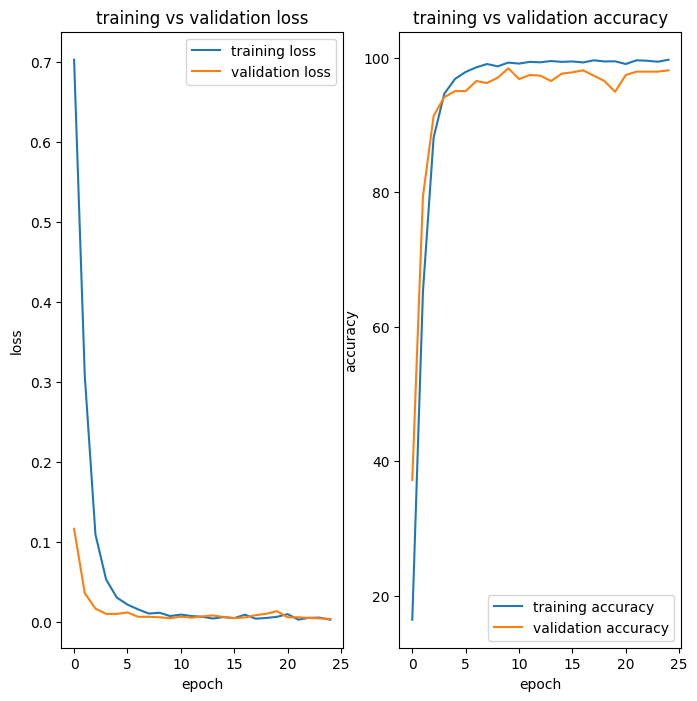

In [16]:
fig,axs=plt.subplots(1,2,figsize=(8,8))
axs[0].plot(total_loss_train_plt,label="training loss")
axs[0].plot(total_loss_val_plt,label="validation loss")
axs[0].set_title('training vs validation loss')
axs[0].set_xlabel('epoch')
axs[0].set_ylabel('loss')
axs[0].legend()

axs[1].plot(total_acc_train_plt,label="training accuracy")
axs[1].plot(total_acc_val_plt,label="validation accuracy")
axs[1].set_title('training vs validation accuracy')
axs[1].set_xlabel('epoch')
axs[1].set_ylabel('accuracy')
axs[1].legend()
plt.show()